# Load Data

In [1]:
import pandas as pd 
import sqlite3
conn = sqlite3.connect("PortfolioProject2")
cursor = conn.cursor()

In [2]:
df = pd.read_csv("Protocol_Deviation_Table.csv")
df.to_sql("Protocol_Deviation_Table", conn, if_exists="replace", index=False)

50

# SQL Queries

## #1. Which locations has the most deviations?

In [3]:
query = """
SELECT Location, COUNT(*) AS Total_Deviations
FROM Protocol_Deviation_Table
GROUP BY Location
ORDER BY Total_Deviations DESC;
"""

cursor.execute(query)
results = cursor.fetchall()
for row in results:
    print(row)

('Seattle, WA', 5)
('San Diego, CA', 5)
('Portland, OR', 5)
('Phoenix, AZ', 5)
('Miami, FL', 5)
('Denver, CO', 5)
('Dallas, TX', 5)
('Chicago, IL', 5)
('Boston, MA', 5)
('Atlanta, GA', 5)


## #2. Major vs minor deviations by location?

In [4]:
query = """
SELECT Deviation_Type, COUNT(*) AS Total
FROM Protocol_Deviation_Table
GROUP BY Deviation_Type;
"""

cursor.execute(query)
print(cursor.fetchall())

[('Major', 15), ('Minor', 35)]


## #3. What caused deviations the most (top categories)?

In [5]:
query = """
SELECT Category, COUNT(*) AS Total
FROM Protocol_Deviation_Table
GROUP BY Category
ORDER BY Total DESC;
"""

cursor.execute(query)
print(cursor.fetchall())

[('Out-of-window visit', 13), ('Missing lab', 12), ('Missed visit', 10), ('Consent issue', 8), ('Incorrect dose', 7)]


## #4. Which sites had the highest rate of major deviations?

In [6]:
query = """
SELECT Site_ID, COUNT(*) AS Major_Deviations
FROM Protocol_Deviation_Table
WHERE Deviation_Type = 'Major'
GROUP BY Site_ID
ORDER BY Major_Deviations DESC;
"""

cursor.execute(query)
print(cursor.fetchall())

[('SITE08', 5), ('SITE05', 5), ('SITE02', 5)]


## #5. What week/visit has the most deviations?

In [7]:
query = """
SELECT Visit, COUNT(*) AS Total
FROM Protocol_Deviation_Table
GROUP BY Visit
ORDER BY Total DESC;
"""

cursor.execute(query)
print(cursor.fetchall())

[('Week 8', 10), ('Week 4', 9), ('Week 2', 8), ('Week 12', 8), ('Week 6', 7), ('Week 1', 7), ('Screening', 1)]


## #6. Deviation trends over time

In [8]:
query = """
SELECT
    printf(
        '%02d/%02d',
        CAST(substr(Date, 1, instr(Date, '/') - 1) AS INT),
        CAST(substr(Date, -2) AS INT)
    ) AS Month_Year,
    COUNT(*) AS Total_Deviations
FROM Protocol_Deviation_Table
GROUP BY Month_Year
ORDER BY Month_Year;
"""

cursor.execute(query)
print(cursor.fetchall())

[('02/26', 8), ('03/26', 24), ('04/26', 10), ('05/26', 8)]


# Pandas Analysis

In [9]:
df = pd.read_csv("Protocol_Deviation_Table.csv")
df.head()

,Deviation_ID,Site_ID,Location,Date,Deviation_Type,Category,Visit,Notes
0,1,SITE01,"Phoenix, AZ",3/12/2026,Minor,Out-of-window visit,Week 4,Visit occurred 3 days late.
1,2,SITE02,"Dallas, TX",2/28/2026,Major,Consent issue,Screening,Missing signature on consent form.
2,3,SITE03,"Chicago, IL",4/5/2026,Minor,Missed visit,Week 8,Subject unable to attend.
3,4,SITE04,"Denver, CO",3/18/2026,Minor,Missing lab,Week 2,Lab sample not collected.
4,5,SITE05,"Seattle, WA",5/1/2026,Major,Incorrect dose,Week 12,Higher dose than protocol.


In [10]:
df['Date'] = pd.to_datetime(df['Date'])

In [11]:
df['Month_Year'] = df['Date'].dt.strftime('%m/%y')

In [12]:
monthly_counts = df.groupby('Month_Year').size().reset_index(name='Total_Deviations')
monthly_counts

,Month_Year,Total_Deviations
0,02/26,8
1,03/26,24
2,04/26,10
3,05/26,8


# Seaborn Visualizations

In [13]:
import seaborn as sns 
import matplotlib.pyplot as plt

## #1. Protocol Deviations by Month

<Figure size 1000x500 with 0 Axes>

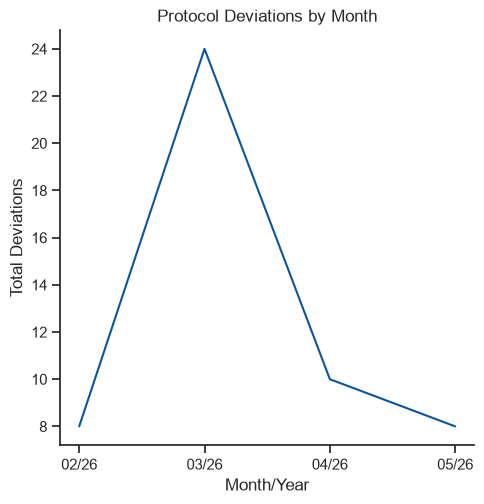

In [31]:
plt.figure(figsize=(10,5))
sns.relplot(data=monthly_counts, kind='line', x='Month_Year', y='Total_Deviations')
plt.title('Protocol Deviations by Month')
plt.xlabel('Month/Year')
plt.ylabel('Total Deviations')
sns.set_theme(style="ticks", palette="Blues_r")
plt.show()

## #2. Major vs Minor Deviations

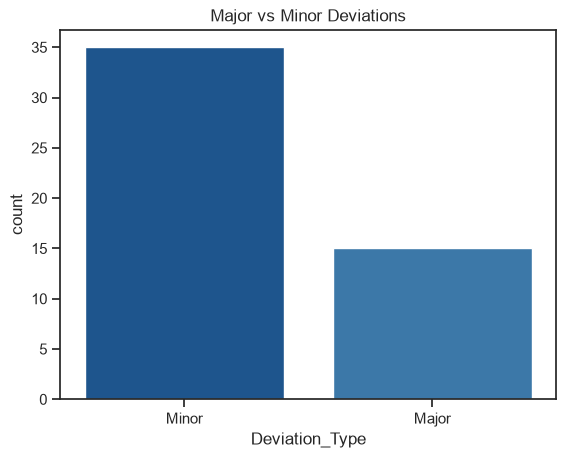

In [30]:
sns.countplot(data=df, x='Deviation_Type', hue='Deviation_Type')
plt.title('Major vs Minor Deviations')
sns.set_theme(style="ticks", palette="Blues_r")
plt.show()

## #3. Top Deviation Categories

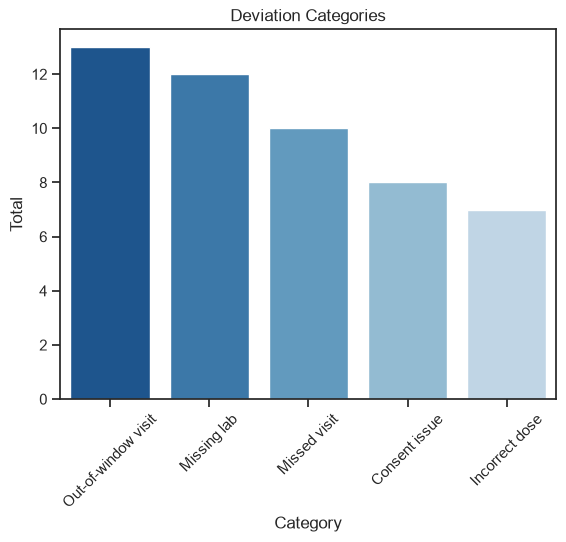

In [29]:
cat_counts = df['Category'].value_counts().reset_index()
cat_counts.columns = ['Category', 'Total']

sns.barplot(data=cat_counts, x='Category', y='Total', hue='Category')
plt.xticks(rotation=45)
plt.title('Deviation Categories')
sns.set_theme(style="ticks", palette="Blues_r")
plt.show()

## #4. Deviations by Visit

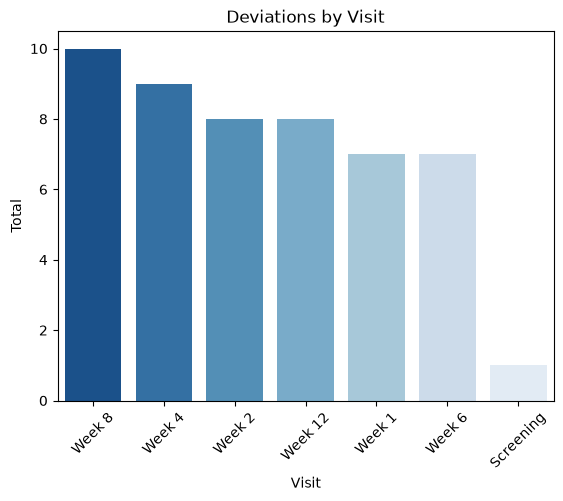

In [17]:
visit_counts = df['Visit'].value_counts().reset_index()
visit_counts.columns = ['Visit', 'Total']

sns.barplot(data=visit_counts, x='Visit', y='Total', hue='Visit', palette='Blues_r')
plt.xticks(rotation=45)
plt.title('Deviations by Visit')
plt.show()

## #5. Deviations by Site

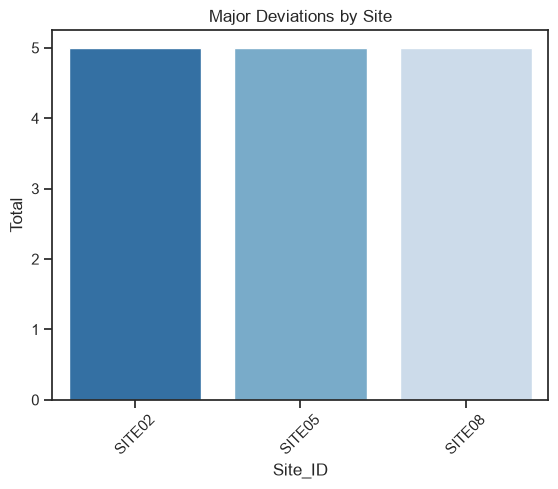

In [32]:
cat_counts = df.groupby(['Site_ID', 'Deviation_Type']).size().reset_index(name='Total')
major_sites = cat_counts[cat_counts['Deviation_Type'] == 'Major']


sns.barplot(
    data=major_sites,
    x='Site_ID', y='Total', 
    hue='Site_ID', 
    palette='Blues_r')
plt.xticks(rotation=45)
plt.title('Major Deviations by Site')
plt.show()

# Insights

1. All 10 cities had equal deviation counts (5 each),

2. Minor deviations were more common (35 vs 15 major).

3. Out-of-window visits and missing labs were the top categories.

4. SITE02, SITE05, and SITE08 had the highest major deviation counts. 

5. Week 8 had the most deviations overall. 

6. March 2026 had the highest deviation volume. 